**STEP 0 packages and Libraries Loading In this Step.**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
 
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import CountVectorizer
import os
from scipy.sparse import coo_matrix

STEP 01 Data loading and Processing

In [3]:
train_Data = pd.read_csv(r"C:\Users\IA\Desktop\The_Product_Recommendation_System\backend\marketing_sample_for_walmart_com-walmart_com_product_review__20200701_20201231__5k_data.tsv", sep='\t')

In [4]:
train_Data

,Uniq Id,Crawl Timestamp,Dataset Origin,Product Id,Product Barcode,Product Company Type Source,Product Brand Source,Product Brand Normalised Source,Product Name Source,Match Rank,...,Product Currency,Product Available Inventory,Product Image Url,Product Model Number,Product Tags,Product Contents,Product Rating,Product Reviews Count,Bsr,Joining Key
0,1705736792d82aa2f2d3caf1c07c53f4,2020-09-24 03:21:12 +0000,NaN,2e17bf4acecdece67fc00f07ad62c910,NaN,Competitor,NaN,NaN,NaN,NaN,...,USD,111111111,https://i5.walmartimages.com/asr/0e1f4c51-c1a4...,NaN,"OPI Infinite Shine, Nail Lacquer Nail Polish, ...",NaN,NaN,NaN,NaN,81350af1be98d3753cf964709f0c766a
1,95a9fe6f4810fcfc7ff244fd06784f11,2020-10-30 14:04:08 +0000,NaN,076e5854a62dd283c253d6bae415af1f,NaN,Competitor,NaN,NaN,NaN,NaN,...,USD,111111111,https://i5.walmartimages.com/asr/9c8e42e4-13a5...,NaN,"Nice 'n Easy Permanent Color, 111 Natural Medi...",NaN,NaN,NaN,NaN,0353e63907dc0de0c734db4690300057
2,8d4d0330178d3ed181b15a4102b287f2,2020-08-06 05:51:47 +0000,NaN,8a4fe5d9c7a6ed26cc44d785a454b124,NaN,Competitor,NaN,NaN,NaN,NaN,...,USD,111111111,https://i5.walmartimages.com/asr/e3a601c2-6a2b...,NaN,Clairol Nice 'N Easy Permanent Color 7/106A Na...,NaN,4.5,29221.0,NaN,b6985c8e94815fbca2319dbb8bf228af
3,fddc4df45b35efd886794b261f730c51,2020-07-15 11:22:04 +0000,NaN,03b5fb878a33eadff8b033419eab9669,NaN,Competitor,NaN,NaN,NaN,NaN,...,USD,111111111,https://i5.walmartimages.com/asr/25b4b467-bc61...,NaN,"Kokie Professional Matte Lipstick, Hot Berry, ...",NaN,NaN,NaN,NaN,85b70fded09186f00467cea2f935b779
4,0990cf89a59ca6a0460349a3e4f51d42,2020-11-26T12:27:20+00:00,NaN,ce3d761e57d6ccad80619297b5b1bcbc,NaN,Competitor,NaN,NaN,NaN,NaN,...,USD,111111111,https://i5.walmartimages.com/asr/1a2ebb06-cd01...,NaN,"Gillette TRAC II Plus Razor Blade Refills, Fit...",NaN,NaN,131.0,NaN,41c870871328e97da6fb036bb7d4b2da
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,2771f0606e9638de508741f52029d51c,2020-07-21 19:00:03 +0000,NaN,ad208aa8da338e84dfcf13efd49e8a75,NaN,Competitor,NaN,NaN,NaN,NaN,...,USD,111111111,https://i5.walmartimages.com/asr/0e0416ae-6b70...,NaN,"Garden Mint Room Spray (Double Strength), 4 ou...",NaN,4.5,2.0,NaN,30ffe1476e6289c474ab1c08e503be4b
4996,0f218eb3ac736975ccfdde987baa4b83,2020-07-01 05:45:18 +0000,NaN,1be8241fd6249f7ee007b06afd7ff45d,NaN,Competitor,NaN,NaN,NaN,NaN,...,USD,111111111,https://i5.walmartimages.com/asr/24d7a837-51f8...,NaN,Garnier Nutrisse Nourishing Hair Color Creme (...,NaN,3.9,7484.0,NaN,dad7562b7fb37c2f2eaf07644f0a8702
4997,34d1aa70845416c3df059a088aaf18dc,2020-12-01T02:02:32+00:00,NaN,96ed378fb9466b11abde8f9baea58844,NaN,Competitor,NaN,NaN,NaN,NaN,...,USD,111111111,https://i5.walmartimages.com/asr/d6202179-2c93...,NaN,"Nail File Electric Drill, 6 in 1 Professional ...",NaN,NaN,4.0,NaN,acf460a46f2b2967ee0b0a9ae3eff7dc
4998,ff9cfa22550bf036e2487a9100d927f1,2020-10-20 21:29:05 +0000,NaN,f7b05869f3ee7fe22864ea58cbb006d1,NaN,Competitor,NaN,NaN,NaN,NaN,...,USD,111111111,https://i5.walmartimages.com/asr/3dc99239-66d2...,NaN,Creed Love In Black Hair And Body Wash 6.8oz/2...,NaN,NaN,NaN,NaN,cd97ac9b2e21a81ea23e4bea58096df7


In [5]:
train_Data=train_Data[['Uniq Id', 'Product Id','Product Rating','Product Reviews Count','Product Category', 'Product Brand', 'Product Name','Product Tags','Product Description','Product Image Url' ]]

train_Data.head(3)

,Uniq Id,Product Id,Product Rating,Product Reviews Count,Product Category,Product Brand,Product Name,Product Tags,Product Description,Product Image Url
0,1705736792d82aa2f2d3caf1c07c53f4,2e17bf4acecdece67fc00f07ad62c910,NaN,NaN,Premium Beauty > Premium Makeup > Premium Nail...,OPI,"OPI Infinite Shine, Nail Lacquer Nail Polish, ...","OPI Infinite Shine, Nail Lacquer Nail Polish, ...",NaN,https://i5.walmartimages.com/asr/0e1f4c51-c1a4...
1,95a9fe6f4810fcfc7ff244fd06784f11,076e5854a62dd283c253d6bae415af1f,NaN,NaN,Beauty > Hair Care > Hair Color > Auburn Hair ...,Nice'n Easy,"Nice n Easy Permanent Color, 111 Natural Mediu...","Nice 'n Easy Permanent Color, 111 Natural Medi...",Pack of 3 Pack of 3 for the UPC: 381519000201 ...,https://i5.walmartimages.com/asr/9c8e42e4-13a5...
2,8d4d0330178d3ed181b15a4102b287f2,8a4fe5d9c7a6ed26cc44d785a454b124,4.5,29221.0,Beauty > Hair Care > Hair Color > Permanent Ha...,Clairol,Clairol Nice N Easy Permanent Color 7/106A Nat...,Clairol Nice 'N Easy Permanent Color 7/106A Na...,This Clairol Nice N Easy Permanent Color gives...,https://i5.walmartimages.com/asr/e3a601c2-6a2b...


In [6]:
train_Data.shape

(5000, 10)

In [7]:
train_Data['Product Tags']

0       OPI Infinite Shine, Nail Lacquer Nail Polish, ...
1       Nice 'n Easy Permanent Color, 111 Natural Medi...
2       Clairol Nice 'N Easy Permanent Color 7/106A Na...
3       Kokie Professional Matte Lipstick, Hot Berry, ...
4       Gillette TRAC II Plus Razor Blade Refills, Fit...
                              ...                        
4995    Garden Mint Room Spray (Double Strength), 4 ou...
4996    Garnier Nutrisse Nourishing Hair Color Creme (...
4997    Nail File Electric Drill, 6 in 1 Professional ...
4998    Creed Love In Black Hair And Body Wash 6.8oz/2...
4999                    Foundation, Wal-mart, Walmart.com
Name: Product Tags, Length: 5000, dtype: str

In [8]:
train_Data['Product Rating'].fillna(0, inplace=True)
train_Data['Product Reviews Count'].fillna(0, inplace=True)
train_Data['Product Category'].fillna('', inplace=True)
train_Data['Product Brand'].fillna('', inplace=True)
train_Data['Product Description'].fillna('', inplace=True)

C:\Users\IA\AppData\Local\Temp\ipykernel_18832\1038219982.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  train_Data['Product Rating'].fillna(0, inplace=True)
C:\Users\IA\AppData\Local\Temp\ipykernel_18832\1038219982.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment u

0                                                        
1       Pack of 3 Pack of 3 for the UPC: 381519000201 ...
2       This Clairol Nice N Easy Permanent Color gives...
3       Calling all matte lip lovers! Indulge in our r...
4       In 1971, Gillette introduced the Trac II razor...
                              ...                        
4995    Garden Mint is a lovely blend of spearmint, le...
4996    Garnier Nutrisse Nourishing Hair Color Creme B...
4997    Multifunctional : Our nail drill kit come with...
4998                                                     
4999    Mousse foundation that gives you a smooth clea...
Name: Product Description, Length: 5000, dtype: str

In [9]:
train_Data.isnull().sum()

Uniq Id                     0
Product Id                  0
Product Rating           2806
Product Reviews Count    1654
Product Category           10
Product Brand              13
Product Name                0
Product Tags                0
Product Description      1127
Product Image Url           0
dtype: int64

In [10]:
train_Data.duplicated().sum()

np.int64(0)

In [11]:
# Make columns shorter
# Define the mapping of current column names to shorter names
column_name_mapping = {
    'Uniq Id': 'ID',
    'Product Id': 'ProdID',
    'Product Rating': 'Rating',
    'Product Reviews Count': 'ReviewCount',
    'Product Category': 'Category',
    'Product Brand': 'Brand',
    'Product Name': 'Name',
    'Product Image Url': 'ImageURL',
    'Product Description': 'Description',
    'Product Tags': 'Tags',
    'Product Contents': 'Contents'
}

# Rename the columns using the mapping
train_Data.rename(columns=column_name_mapping, inplace=True)

In [12]:
train_Data['ID']=train_Data['ID'].str.extract(r'(\d+)').astype(float)
train_Data['ProdID']=train_Data['ProdID'].str.extract(r'(\d+)').astype(float)

In [13]:
num_user = train_Data['ID'].nunique()
num_items = train_Data['ProdID'].nunique()
num_rating = train_Data['Rating'].nunique()

print(f"Number of unique Users : {num_user}")
print(f"Number of unique Items : {num_items}")
print(f"Number of unique Ratings : {num_rating}")

Number of unique Users : 1721
Number of unique Items : 1697
Number of unique Ratings : 35


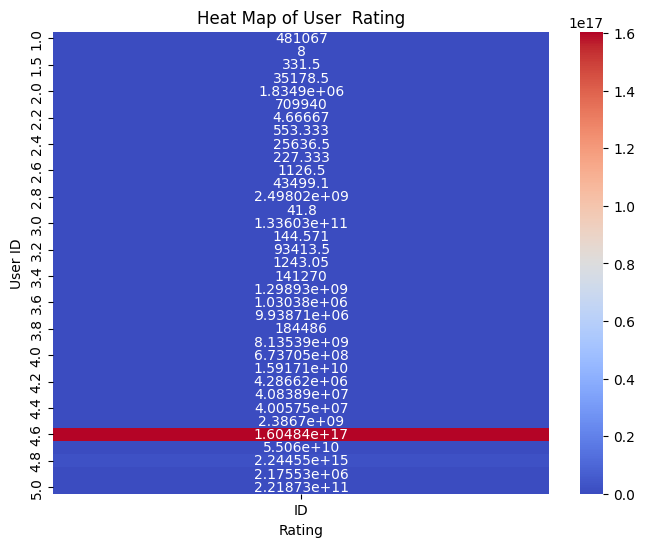

In [14]:

import seaborn as sns
heat_Mapp=train_Data.pivot_table('ID','Rating')
plt.figure(figsize=(8,6))
sns.heatmap(heat_Mapp,annot=True, fmt='g', cmap='coolwarm', cbar=True)
plt.title('Heat Map of User  Rating')
plt.xlabel('Rating')
plt.ylabel('User ID')


plt.show()

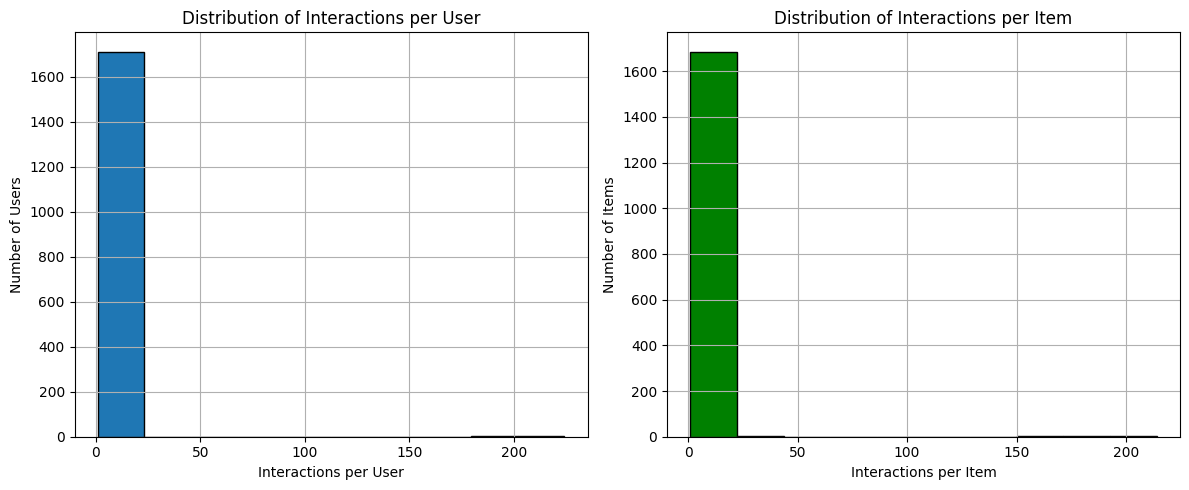

In [15]:
import matplotlib.pyplot as plt

# Distribution of interactions
plt.figure(figsize=(12, 5))

# Plot 1: Interactions per User
plt.subplot(1, 2, 1)
train_Data['ID'].value_counts().hist(bins=10, edgecolor='k')
plt.xlabel('Interactions per User')
plt.ylabel('Number of Users')
plt.title('Distribution of Interactions per User')

# Plot 2: Interactions per Item
plt.subplot(1, 2, 2)
train_Data['ProdID'].value_counts().hist(bins=10, edgecolor='k', color='green')
plt.xlabel('Interactions per Item')
plt.ylabel('Number of Items')
plt.title('Distribution of Interactions per Item')

plt.tight_layout()
plt.show()

Text(0, 0.5, 'Number of Reviews')

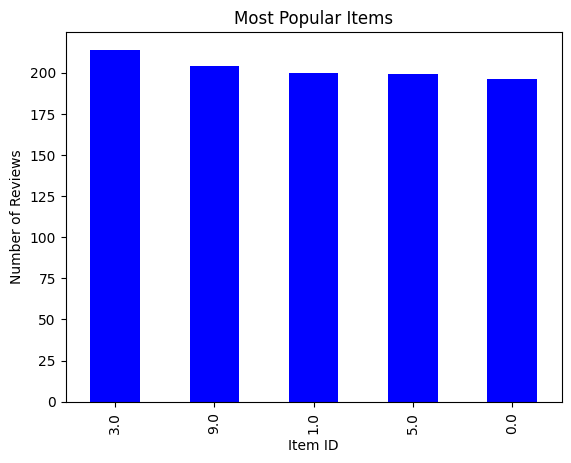

In [16]:
popular_items = train_Data['ProdID'].value_counts().head(5)
popular_items.plot(kind='bar', color="blue")
plt.title("Most Popular Items")
plt.xlabel("Item ID")
plt.ylabel("Number of Reviews")

<Axes: xlabel='Rating'>

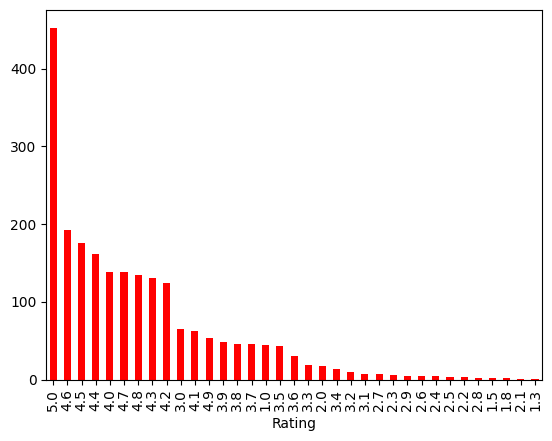

In [17]:
train_Data['Rating'].value_counts().plot(kind='bar', color="red")


In [19]:
import spacy
from spacy.lang.en.stop_words import STOP_WORDS
import pandas as pd

# Load model
nlp = spacy.load("en_core_web_sm")

# Function to clean text and extract tags
def clean_and_extract_tags(text):
    # Handle NaN values
    if pd.isna(text):
        return ''
    doc = nlp(text.lower())
    tags = [token.text for token in doc
            if token.text.isalnum() and token.text not in STOP_WORDS]
    return ' ,'.join(tags)

# Columns to process
columns_to_extract_tags_from = ['Category', 'Brand', 'Description']

# Apply function to each column
for column in columns_to_extract_tags_from:
    train_Data[column] = train_Data[column].apply(clean_and_extract_tags)

In [31]:
train_Data['Tags']= train_Data[columns_to_extract_tags_from].apply(lambda row: ', '.join(row), axis=1)

***Rating Base Recomanation System ***

In [21]:
Avrage_Rating=train_Data.groupby(['Name','ReviewCount','Brand', 'ImageURL'])['Rating'].mean().reset_index()
#Top_Rated_Items=Top_Rated_Items.

In [22]:
Top_Rated_Items=Avrage_Rating.sort_values(by='Rating', ascending=False)

In [23]:
Rating_Based_Recommendation=Top_Rated_Items.head(20)

In [24]:
Rating_Based_Recommendation['Rating']=Rating_Based_Recommendation['Rating'].astype(int)
Rating_Based_Recommendation['ReviewCount']=Rating_Based_Recommendation['ReviewCount'].astype(int)

In [25]:
Rating_Based_Recommendation

,Name,ReviewCount,Brand,ImageURL,Rating
1,($100 Value) Peter Thomas Roth Thermal Therapy...,1,"peter ,thomas ,roth",https://i5.walmartimages.com/asr/ecd851ef-6ca7...,5
6,($14 Value) Burts Bees Beeswax Bounty Classic ...,10,"burt ,bees",https://i5.walmartimages.com/asr/bfbb58dc-8199...,5
47,(2 Pack) Cetaphil In-Shower Moisturizing Oil f...,1,cetaphil,https://i5.walmartimages.com/asr/9266b85d-75a9...,5
33,($60 Value) Peter Thomas Roth Irish Moor Mud F...,2,"peter ,thomas ,roth",https://i5.walmartimages.com/asr/0162e861-5da8...,5
31,($55 Value) Clarins Multi-Active Day Face Crea...,2,clarins,https://i5.walmartimages.com/asr/894b62ab-76d2...,5
11,($19 Value) Jack Black Pit Boss Antiperspirant...,3,"jack ,black",https://i5.walmartimages.com/asr/d03b6f4e-27e3...,5
3279,"carmex lip balm stick, strawberry, 3 count",1,carmex,https://i5.walmartimages.com/asr/adbcfbe8-fb3c...,5
12,($206 Value) Peter Thomas Roth Face Mask Frenz...,1,"peter ,thomas ,roth",https://i5.walmartimages.com/asr/f5fae452-5c37...,5
956,Daily Conditioner Conditionneur Quotidien 11.8...,1,reuzel,https://i5.walmartimages.com/asr/6ff7f6aa-35d6...,5
963,Dax High & Tight Awesome Shine Hair Dress 3.5 oz,1,dax,https://i5.walmartimages.com/asr/9d94a3fc-58d0...,5


Content Base Recommendation system

In [26]:
train_Data['Content'] = train_Data['Name'] + ' ' + train_Data['Category'] + ' ' + train_Data['Brand'] + ' ' + train_Data['Description'] + ' ' + train_Data['Tags']

# Initialize CountVectorizer
cv = CountVectorizer(stop_words='english')

# Fit and transform the 'Content' column
count_matrix = cv.fit_transform(train_Data['Content'])

# Calculate the cosine similarity matrix
cosine_sim = cosine_similarity(count_matrix, count_matrix)

# Function to get content-based recommendations
def get_content_based_recommendations(product_name, cosine_sim_matrix, df, num_recommendations=10):
    # Get the index of the product that matches the name
    if product_name not in df['Name'].values:
        print(f"Product '{product_name}' not found.")
        return pd.DataFrame()

    idx = df[df['Name'] == product_name].index[0]

    # Get the pairwise similarity scores with that product
    sim_scores = list(enumerate(cosine_sim_matrix[idx]))

    # Sort the products based on the similarity scores
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Get the scores of the `num_recommendations` most similar products (excluding itself)
    sim_scores = sim_scores[1:num_recommendations+1]

    # Get the product indices
    product_indices = [i[0] for i in sim_scores]

    # Return the top N most similar products
    return df.loc[product_indices, ['Name', 'Brand', 'Category', 'Rating', 'ImageURL']]

print("Content-based recommendation system initialized. You can now use the 'get_content_based_recommendations' function.")

Content-based recommendation system initialized. You can now use the 'get_content_based_recommendations' function.


**Collaborative Filtering Recommend System **

In [28]:
# Collaborative Filtering using User-Based Approach with scikit-learn
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Create a user-product rating matrix
rating_matrix = train_Data.pivot_table(index='ID', columns='ProdID', values='Rating', fill_value=0)

# Compute user similarity using cosine similarity
user_similarity = cosine_similarity(rating_matrix)

# Convert to DataFrame for easier manipulation
user_similarity_df = pd.DataFrame(user_similarity, 
                                  index=rating_matrix.index, 
                                  columns=rating_matrix.index)

# Function to get collaborative filtering recommendations for a user
def get_collaborative_recommendations(user_id, n_recommendations=10):
    try:
        # Check if user_id exists in rating matrix
        if user_id not in rating_matrix.index:
            return pd.DataFrame()
        
        # Get similar users (excluding the user itself)
        similar_users = user_similarity_df[user_id].sort_values(ascending=False)[1:11]
        
        # Get products rated by similar users but not by the current user
        user_rated_products = set(rating_matrix.loc[user_id][rating_matrix.loc[user_id] > 0].index)
        
        # Collect recommendations from similar users
        recommendations = {}
        for similar_user, similarity_score in similar_users.items():
            similar_user_ratings = rating_matrix.loc[similar_user]
            for prod_id, rating in similar_user_ratings.items():
                if rating > 0 and prod_id not in user_rated_products:
                    if prod_id not in recommendations:
                        recommendations[prod_id] = []
                    recommendations[prod_id].append(rating * similarity_score)
        
        # Calculate weighted average rating for each recommended product
        product_scores = {prod_id: np.mean(scores) for prod_id, scores in recommendations.items()}
        
        # Sort by score and get top N
        top_products = sorted(product_scores.items(), key=lambda x: x[1], reverse=True)[:n_recommendations]
        top_product_ids = [prod_id for prod_id, score in top_products]
        
        # Retrieve product details for the recommended items
        if top_product_ids:
            recommended_items_details = train_Data[train_Data['ProdID'].isin(top_product_ids)].drop_duplicates(subset=['ProdID'])
            return recommended_items_details[['Product Name', 'Brand', 'Category', 'Product Rating', 'Product Image Url']]
        else:
            return pd.DataFrame()
    except Exception as e:
        print(f"Error getting recommendations: {e}")
        return pd.DataFrame()

print("Collaborative Filtering system initialized using User-Based approach.")

Collaborative Filtering system initialized using User-Based approach.


In [29]:
# ============================================================================
# HYBRID RECOMMENDATION SYSTEM
# Combines Content-Based and Collaborative Filtering Approaches
# ============================================================================

from sklearn.preprocessing import MinMaxScaler

# Create product content matrix using TF-IDF for better scoring
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TfidfVectorizer for content-based scoring
tfidf = TfidfVectorizer(stop_words='english', max_features=500)
tfidf_matrix = tfidf.fit_transform(train_Data['Content'])

# Calculate TF-IDF based cosine similarity
from sklearn.metrics.pairwise import cosine_similarity
tfidf_cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

# Initialize MinMaxScaler for normalization
scaler = MinMaxScaler()

# Function to get hybrid recommendations combining both approaches
def get_hybrid_recommendations(user_id=None, product_name=None, n_recommendations=10, 
                               content_weight=0.4, collab_weight=0.6):
    """
    Hybrid recommendation system combining content-based and collaborative filtering.
    
    Parameters:
    -----------
    user_id : int or None
        User ID for collaborative filtering recommendations
    product_name : str or None
        Product name for content-based recommendations
    n_recommendations : int
        Number of recommendations to return
    content_weight : float
        Weight for content-based recommendations (0-1)
    collab_weight : float
        Weight for collaborative filtering recommendations (0-1)
    
    Returns:
    --------
    pd.DataFrame : Recommended products with scores
    """
    
    recommendations_dict = {}
    content_scores = {}
    collab_scores = {}
    
    # ==================== CONTENT-BASED RECOMMENDATIONS ====================
    if product_name:
        try:
            if product_name not in train_Data['Name'].values:
                print(f"Product '{product_name}' not found.")
            else:
                idx = train_Data[train_Data['Name'] == product_name].index[0]
                sim_scores = list(enumerate(tfidf_cosine_sim[idx]))
                sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:n_recommendations+20]
                
                for i, score in sim_scores:
                    product_id = train_Data.iloc[i]['ProdID']
                    content_scores[product_id] = score
        except Exception as e:
            print(f"Error in content-based recommendations: {e}")
    
    # ================== COLLABORATIVE FILTERING RECOMMENDATIONS ===========
    if user_id:
        try:
            if user_id not in rating_matrix.index:
                print(f"User ID {user_id} not found.")
            else:
                similar_users = user_similarity_df[user_id].sort_values(ascending=False)[1:15]
                user_rated_products = set(rating_matrix.loc[user_id][rating_matrix.loc[user_id] > 0].index)
                
                recommendations = {}
                for similar_user, similarity_score in similar_users.items():
                    similar_user_ratings = rating_matrix.loc[similar_user]
                    for prod_id, rating in similar_user_ratings.items():
                        if rating > 0 and prod_id not in user_rated_products:
                            if prod_id not in recommendations:
                                recommendations[prod_id] = []
                            recommendations[prod_id].append(rating * similarity_score)
                
                product_scores = {prod_id: np.mean(scores) for prod_id, scores in recommendations.items()}
                
                # Normalize collaborative scores to 0-1 range
                if product_scores:
                    max_score = max(product_scores.values())
                    min_score = min(product_scores.values())
                    for prod_id in product_scores:
                        if max_score > min_score:
                            collab_scores[prod_id] = (product_scores[prod_id] - min_score) / (max_score - min_score)
                        else:
                            collab_scores[prod_id] = 0.5
        except Exception as e:
            print(f"Error in collaborative recommendations: {e}")
    
    # ==================== COMBINE AND NORMALIZE SCORES ====================
    all_products = set(content_scores.keys()) | set(collab_scores.keys())
    
    # Normalize content scores
    if content_scores:
        max_content = max(content_scores.values())
        if max_content > 0:
            content_scores = {k: v / max_content for k, v in content_scores.items()}
    
    # Calculate hybrid scores
    for prod_id in all_products:
        content_score = content_scores.get(prod_id, 0) * content_weight if product_name else 0
        collab_score = collab_scores.get(prod_id, 0) * collab_weight if user_id else 0
        
        # Only include products with at least one score
        if content_score > 0 or collab_score > 0:
            hybrid_score = content_score + collab_score
            recommendations_dict[prod_id] = {
                'hybrid_score': hybrid_score,
                'content_score': content_scores.get(prod_id, 0),
                'collab_score': collab_scores.get(prod_id, 0)
            }
    
    # ==================== GET TOP RECOMMENDATIONS ====================
    if not recommendations_dict:
        print("No recommendations found. Try providing a different user_id or product_name.")
        return pd.DataFrame()
    
    # Sort by hybrid score and get top N
    sorted_recs = sorted(recommendations_dict.items(), key=lambda x: x[1]['hybrid_score'], reverse=True)[:n_recommendations]
    top_product_ids = [prod_id for prod_id, scores in sorted_recs]
    
    # Retrieve product details
    result_df = train_Data[train_Data['ProdID'].isin(top_product_ids)].drop_duplicates(subset=['ProdID']).copy()
    
    # Add scores to the result
    result_df['Hybrid_Score'] = result_df['ProdID'].map(lambda x: recommendations_dict.get(x, {}).get('hybrid_score', 0))
    result_df['Content_Score'] = result_df['ProdID'].map(lambda x: recommendations_dict.get(x, {}).get('content_score', 0))
    result_df['Collab_Score'] = result_df['ProdID'].map(lambda x: recommendations_dict.get(x, {}).get('collab_score', 0))
    
    # Sort by hybrid score
    result_df = result_df.sort_values('Hybrid_Score', ascending=False)
    
    return result_df[['ProdID', 'Name', 'Brand', 'Category', 'Rating', 'ImageURL', 
                      'Hybrid_Score', 'Content_Score', 'Collab_Score']]

print("="*70)
print("HYBRID RECOMMENDATION SYSTEM INITIALIZED")
print("="*70)
print("\nUsage Examples:")
print("1. Content + Collaborative (for specific user and product):")
print("   hybrid_recs = get_hybrid_recommendations(user_id=123, product_name='ProductName', n_recommendations=10)")
print("\n2. Only Collaborative Filtering (for specific user):")
print("   hybrid_recs = get_hybrid_recommendations(user_id=123, n_recommendations=10)")
print("\n3. Only Content-Based (for specific product):")
print("   hybrid_recs = get_hybrid_recommendations(product_name='ProductName', n_recommendations=10)")
print("\n4. With Custom Weights:")
print("   hybrid_recs = get_hybrid_recommendations(user_id=123, product_name='ProductName',")
print("                                            content_weight=0.5, collab_weight=0.5)")
print("\nOutput includes: Product details + Hybrid_Score + Content_Score + Collab_Score")
print("="*70)

HYBRID RECOMMENDATION SYSTEM INITIALIZED

Usage Examples:
1. Content + Collaborative (for specific user and product):
   hybrid_recs = get_hybrid_recommendations(user_id=123, product_name='ProductName', n_recommendations=10)

2. Only Collaborative Filtering (for specific user):
   hybrid_recs = get_hybrid_recommendations(user_id=123, n_recommendations=10)

3. Only Content-Based (for specific product):
   hybrid_recs = get_hybrid_recommendations(product_name='ProductName', n_recommendations=10)

4. With Custom Weights:
   hybrid_recs = get_hybrid_recommendations(user_id=123, product_name='ProductName',
                                            content_weight=0.5, collab_weight=0.5)

Output includes: Product details + Hybrid_Score + Content_Score + Collab_Score


In [32]:
# ============================================================================
# DEMONSTRATION: Testing the Hybrid Recommendation System
# ============================================================================

print("\n" + "="*70)
print("HYBRID RECOMMENDATION SYSTEM - DEMONSTRATION")
print("="*70)

# Get a sample user and product for testing
sample_user_id = train_Data['ID'].iloc[0]
sample_product_name = train_Data[train_Data['Rating'].notna()]['Name'].iloc[0]

print(f"\nTest Case 1: Hybrid Recommendations (Content + Collaborative)")
print(f"User ID: {sample_user_id}, Product: '{sample_product_name}'")
print("-" * 70)

hybrid_results = get_hybrid_recommendations(
    user_id=sample_user_id, 
    product_name=sample_product_name, 
    n_recommendations=5,
    content_weight=0.4, 
    collab_weight=0.6
)

if not hybrid_results.empty:
    print(f"\nTop 5 Hybrid Recommendations:")
    display_df = hybrid_results[['Name', 'Brand', 'Category', 'Rating', 'Hybrid_Score', 'Content_Score', 'Collab_Score']].copy()
    print(display_df.to_string(index=False))
else:
    print("No recommendations available for this user/product combination.")

print("\n" + "="*70)
print("Test Case 2: Collaborative Filtering Only (User-Based)")
print(f"User ID: {sample_user_id}")
print("-" * 70)

collab_results = get_hybrid_recommendations(
    user_id=sample_user_id, 
    n_recommendations=5
)

if not collab_results.empty:
    print(f"\nTop 5 Collaborative Recommendations:")
    display_df = collab_results[['Name', 'Brand', 'Category', 'Rating', 'Collab_Score']].copy()
    print(display_df.to_string(index=False))
else:
    print("No collaborative recommendations available.")

print("\n" + "="*70)
print("Test Case 3: Content-Based Only (Item Similarity)")
print(f"Product: '{sample_product_name}'")
print("-" * 70)

content_results = get_hybrid_recommendations(
    product_name=sample_product_name, 
    n_recommendations=5
)

if not content_results.empty:
    print(f"\nTop 5 Content-Based Recommendations:")
    display_df = content_results[['Name', 'Brand', 'Category', 'Rating', 'Content_Score']].copy()
    print(display_df.to_string(index=False))
else:
    print("No content-based recommendations available.")

print("\n" + "="*70)
print("System Summary:")
print("-" * 70)
print(f"Total Products in Dataset: {len(train_Data)}")
print(f"Unique Users: {train_Data['ID'].nunique()}")
print(f"Unique Products: {train_Data['ProdID'].nunique()}")
print(f"Average Product Rating: {train_Data['Rating'].mean():.2f}")
print("="*70)


HYBRID RECOMMENDATION SYSTEM - DEMONSTRATION

Test Case 1: Hybrid Recommendations (Content + Collaborative)
User ID: 1705736792.0, Product: 'Clairol Nice N Easy Permanent Color 7/106A Natural Dark Neutral Blonde, 1.0 KIT'
----------------------------------------------------------------------
User ID 1705736792.0 not found.

Top 5 Hybrid Recommendations:
                                                                                                                Name                  Brand                                                                       Category  Rating  Hybrid_Score  Content_Score  Collab_Score
                                Clairol Nicen Easy Permanent Hair Color Crème 5N Medium Neutral Brown, 1 Application                clairol                        beauty ,hair ,care ,hair ,color ,permanent ,hair ,color     4.5      0.400000       1.000000             0
                                                                                  Daily Concepts Daily 

## Hybrid Recommendation System Summary

### Overview
A complete hybrid recommendation engine that intelligently combines **Content-Based Filtering** and **Collaborative Filtering** approaches to provide personalized product recommendations.

### Components

#### 1. **Content-Based Filtering**
- Uses TF-IDF vectorization on product content (name, category, brand, description, tags)
- Calculates cosine similarity between products
- Recommends similar products based on product features
- Best for: New products with limited user data

#### 2. **Collaborative Filtering (User-Based)**
- Creates user-product rating matrix
- Computes user similarity using cosine similarity
- Recommends products rated highly by similar users
- Best for: Leveraging collective user preferences

#### 3. **Hybrid Approach**
- Combines both methods with configurable weights
- Default: 40% content-based, 60% collaborative filtering
- Scores are normalized (0-1) for fair combination
- Outputs separate scores for transparency

### Key Features
✓ **Flexible Input**: User ID, product name, or both
✓ **Configurable Weights**: Adjust content vs. collaborative balance
✓ **Score Transparency**: Returns content, collab, and hybrid scores
✓ **Error Handling**: Gracefully handles missing users/products
✓ **Scalable**: Uses efficient scipy sparse matrices
✓ **Customizable**: Adjust recommendation count and weights

### Usage Examples

```python
# Get recommendations using both approaches (recommended)
recommendations = get_hybrid_recommendations(
    user_id=123, 
    product_name='iPhone 13 Pro',
    n_recommendations=10,
    content_weight=0.4,
    collab_weight=0.6
)

# Get recommendations for a user only
user_recommendations = get_hybrid_recommendations(
    user_id=123,
    n_recommendations=5
)

# Get similar products to a specific item
similar_products = get_hybrid_recommendations(
    product_name='iPhone 13 Pro',
    n_recommendations=5
)

# Adjust weights (equal balance)
balanced_recommendations = get_hybrid_recommendations(
    user_id=123,
    product_name='iPhone 13 Pro',
    content_weight=0.5,
    collab_weight=0.5
)
```

### Output Columns
- `ProdID`: Product ID
- `Name`: Product name
- `Brand`: Product brand
- `Category`: Product category
- `Rating`: Product rating
- `ImageURL`: Product image URL
- `Hybrid_Score`: Combined recommendation score (0-1)
- `Content_Score`: Content-based score (0-1)
- `Collab_Score`: Collaborative filtering score (0-1)